# Function test:

---

**@dev_note:** I simplified this file by splitting the functions I presented in AlgorithmTest.ipynb into separate files. Each file is well commented, and every parameter includes an explanation and documentation.

**This file was created exclusively to test and validate the results of various test cases.**


## Slodar function: Docs


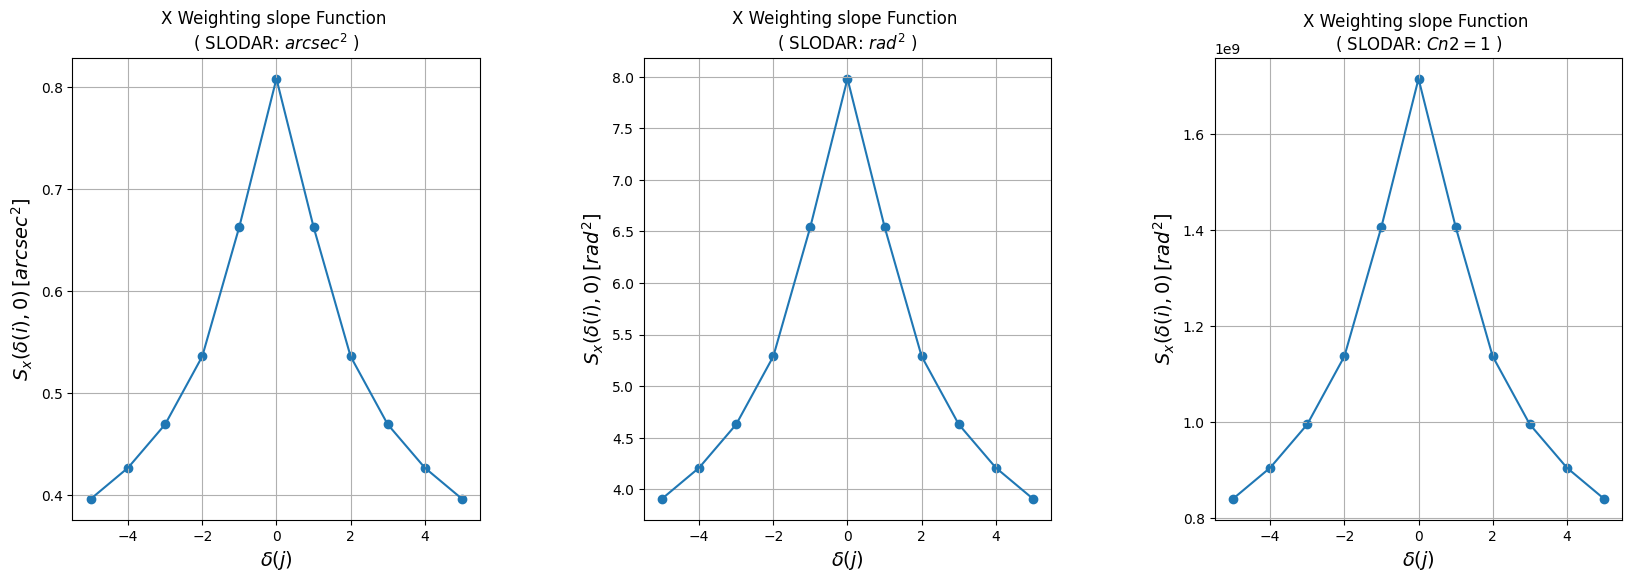

In [1]:
# SLODAR Function

import numpy as np
import matplotlib.pyplot as plt
from SLODAR import slopecov_kol
from aotools.turbulence import r0_to_cn2,cn2_to_r0
# --- Example params ---

d = 0.047                     # sub-aperture size
nsubx = 6                     # sub-apertures 
lamda = 500e-9                # lamda 
scalingRad =(np.pi)**2        # Rad result

## --- Result on arcsec2 ---
Arcov = slopecov_kol(nsubx, d, lamda,  nsamp=8, scalingFactor=1, r0=1) 

## --- Result on rad2 ---
Radcov = slopecov_kol(nsubx, d, lamda, nsamp=8, scalingFactor=scalingRad, r0=1) 

## --- Result on scaling r0=1 to cn2=1 on rad2 ---
Cncov = slopecov_kol(nsubx, d, lamda,  nsamp=8, scalingFactor=1, r0=cn2_to_r0(1,lamda)*500) 

GRID_SIZE = 2 * nsubx - 1
BEAM = 1


# --- graphs ---

fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.4)  

ax1 = fig.add_subplot(gs[0,0])
ax1.plot(np.arange(-5, 6),Arcov[0,:,5],)
ax1.scatter(np.arange(-5, 6),Arcov[0,:,5],)
ax1.set_title('X Weighting slope Function \n' + r'( SLODAR: $arcsec^2$ )')
ax1.set_ylabel(r'$S_x(\delta(i),0)\,[arcsec^2]$', fontsize=14)
ax1.set_xlabel(r'$\delta(j)$', fontsize=14)
ax1.grid("both")

ax2 = fig.add_subplot(gs[0,1])
ax2.plot(np.arange(-5, 6),Radcov[0,:,5],)
ax2.scatter(np.arange(-5, 6),Radcov[0,:,5],)
ax2.set_title('X Weighting slope Function \n' + r'( SLODAR: $rad^2$ )')
ax2.set_ylabel(r'$S_x(\delta(i),0)\,[rad^2]$', fontsize=14)
ax2.set_xlabel(r'$\delta(j)$', fontsize=14)
ax2.grid("both")


ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(np.arange(-5, 6),Cncov[0,:,5],)
ax3.scatter(np.arange(-5, 6),Cncov[0,:,5],)
ax3.set_title('X Weighting slope Function \n' + r'( SLODAR: $Cn2 = 1$ )')
ax3.set_ylabel(r'$S_x(\delta(i),0)\,[rad^2]$', fontsize=14)
ax3.set_xlabel(r'$\delta(j)$', fontsize=14)
ax3.grid("both")


# Z-tilt filter method: Docs.

In this section, we show how to use the function that generates the covariance matrix using the Fourier-based Z-tilt method.

**Index:**

- Function input parameters
- Output in arcsec²
- Output in rad²
- Output at different altitudes
- Tip-tilt subtraction


Text(0, 0.5, '$\\delta(j)$')

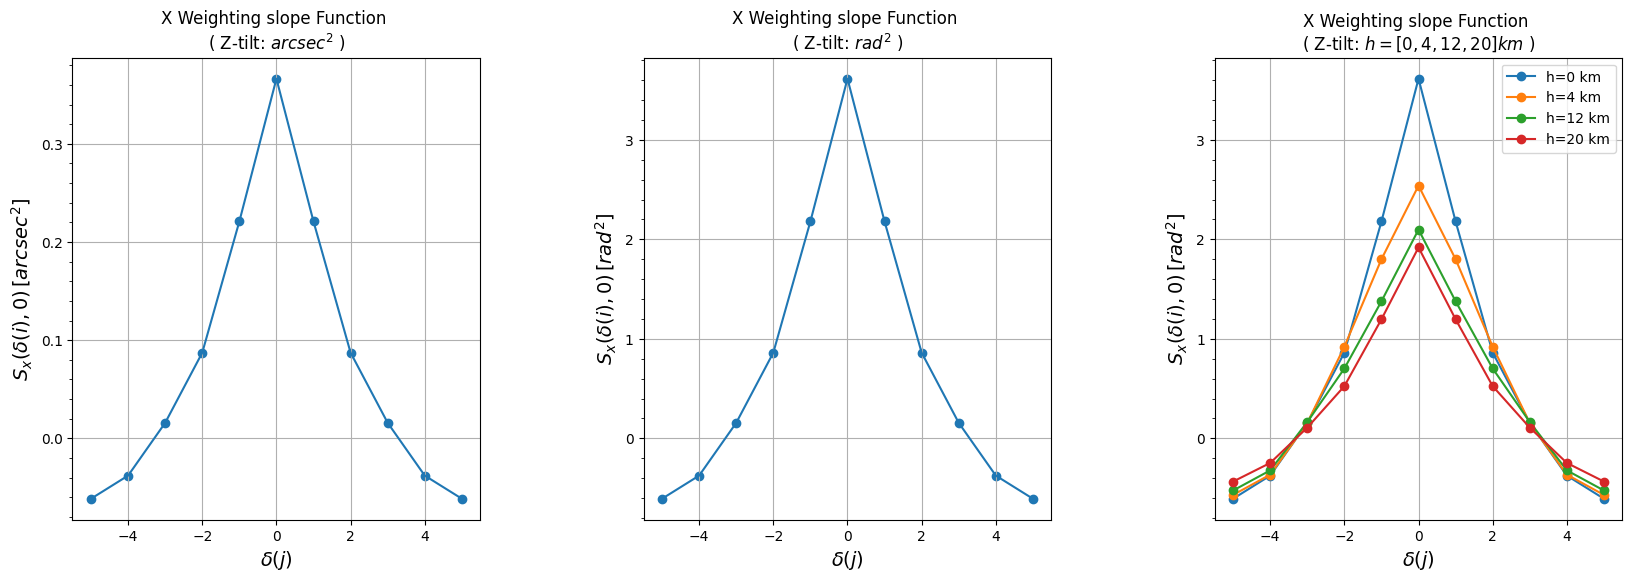

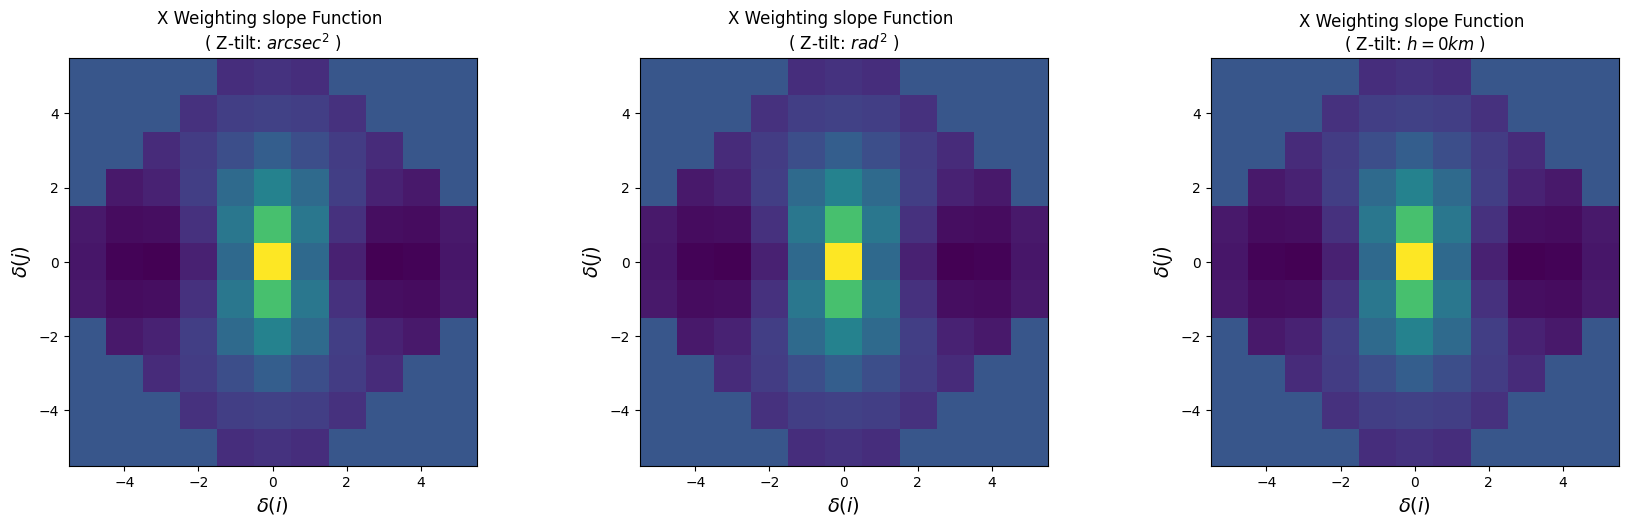

In [1]:
# --- Imports ---
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np
from TTsubstraction import tip_tilt_sub
from Zfilter import weighting_function

# --- Example params ---

d = 0.047                     # sub-aperture size
nsubx = 6                     # sub-apertures 
lamda = 1280e-9               # lamda 
scalingArcsec = (1/np.pi)**2  # result on arcsec
samp = 1024                   # FFT grid size (higher => smaller df, better convergence)
cn2r0 = 1                     # Cn2 or R0
dx = d / 2                    # spatial-lag sampling for IFFT [m]; gives f_max=1/d and total bandwidth ~2/d, then stride=2 selects lags at multiples of d
pupil = np.array([[0,0,1,1,0,0], 
                  [0,1,1,1,1,0],
                  [1,1,0,0,1,1],
                  [1,1,0,0,1,1],
                  [0,1,1,1,1,0],
                  [0,0,1,1,0,0]])



## --- Result on arcsec2 ---
Arcov = weighting_function(d, dx, nsubx, samp, cn2r0=cn2r0, h=0, wavelength=lamda, scalingFactor=scalingArcsec, glob = False)

## --- Result on rad2 ---
Radcov = weighting_function(d, dx, nsubx, samp, cn2r0=cn2r0, h=0 , wavelength=lamda, scalingFactor=1, glob = False)

## --- Diferent h ---
cov1 = weighting_function(d, dx, nsubx, samp, cn2r0=cn2r0, h=0   , wavelength=lamda, scalingFactor=1, glob = False)
cov2 = weighting_function(d, dx, nsubx, samp, cn2r0=cn2r0, h=4e3 , wavelength=lamda, scalingFactor=1, glob = False)
cov3 = weighting_function(d, dx, nsubx, samp, cn2r0=cn2r0, h=12e3, wavelength=lamda, scalingFactor=1, glob = False)
cov4 = weighting_function(d, dx, nsubx, samp, cn2r0=cn2r0, h=20e3, wavelength=lamda, scalingFactor=1, glob = False)


## --- Tip-tilt substraction ---
Apsf = tip_tilt_sub(Arcov,pupil)
Rpsf = tip_tilt_sub(Radcov,pupil)

psf1 = tip_tilt_sub(cov1, pupil)
psf2 = tip_tilt_sub(cov2, pupil)
psf3 = tip_tilt_sub(cov3, pupil)
psf4 = tip_tilt_sub(cov4, pupil)

GRID_SIZE = nsubx*2 - 1  
LAGS = 1

# --- graphs ---

fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.4)  

ax1 = fig.add_subplot(gs[0,0])
ax1.plot(np.arange(-5, 6),Apsf[1,:,5],)
ax1.scatter(np.arange(-5, 6),Apsf[1,:,5],)
ax1.set_title('X Weighting slope Function \n' + r'( Z-tilt: $arcsec^2$ )')
ax1.set_ylabel(r'$S_x(\delta(i),0)\,[arcsec^2]$', fontsize=14)
ax1.set_xlabel(r'$\delta(j)$', fontsize=14)
ax1.yaxis.set_minor_locator(AutoMinorLocator(5))  # 2 => 1 línea menor entre mayores
ax1.grid("both")

ax2 = fig.add_subplot(gs[0,1])
ax2.plot(np.arange(-5, 6),Rpsf[1,:,5],)
ax2.scatter(np.arange(-5, 6),Rpsf[1,:,5],)
ax2.set_title('X Weighting slope Function \n' + r'( Z-tilt: $rad^2$ )')
ax2.set_ylabel(r'$S_x(\delta(i),0)\,[rad^2]$', fontsize=14)
ax2.set_xlabel(r'$\delta(j)$', fontsize=14)
ax2.yaxis.set_minor_locator(AutoMinorLocator(5))  # 2 => 1 línea menor entre mayores
ax2.grid("both")

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(np.arange(-5, 6),psf1[1,:,5], "-o", label="h=0 km")
ax3.plot(np.arange(-5, 6),psf2[1,:,5], "-o", label="h=4 km")
ax3.plot(np.arange(-5, 6),psf3[1,:,5], "-o", label="h=12 km")
ax3.plot(np.arange(-5, 6),psf4[1,:,5], "-o", label="h=20 km")

ax3.set_title('X Weighting slope Function \n' + r'( Z-tilt: $ h= [0,4,12,20] km $ )')
ax3.set_ylabel(r'$S_x(\delta(i),0)\,[rad^2]$', fontsize=14)
ax3.set_xlabel(r'$\delta(j)$', fontsize=14)
ax3.grid("both")
ax3.yaxis.set_minor_locator(AutoMinorLocator(5))  # 2 => 1 línea menor entre mayores
ax3.legend()

fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.4)  

ax1 = fig.add_subplot(gs[0,0])
ax1.imshow(Apsf[1,:,:],
                 extent=(-GRID_SIZE*LAGS/2, GRID_SIZE*LAGS/2, -GRID_SIZE*LAGS/2, GRID_SIZE*LAGS/2))
ax1.set_title('X Weighting slope Function \n' + r'( Z-tilt: $arcsec^2$ )')
ax1.set_xlabel(r'$\delta(i)$', fontsize=14)
ax1.set_ylabel(r'$\delta(j)$', fontsize=14)

ax2 = fig.add_subplot(gs[0,1])
ax2.imshow(Rpsf[1,:,:],
                 extent=(-GRID_SIZE*LAGS/2, GRID_SIZE*LAGS/2, -GRID_SIZE*LAGS/2, GRID_SIZE*LAGS/2))
ax2.set_title('X Weighting slope Function \n' + r'( Z-tilt: $rad^2$ )')
ax2.set_xlabel(r'$\delta(i)$', fontsize=14)
ax2.set_ylabel(r'$\delta(j)$', fontsize=14)

ax3 = fig.add_subplot(gs[0, 2])
ax3.imshow(psf1[1,:,:],
                 extent=(-GRID_SIZE*LAGS/2, GRID_SIZE*LAGS/2, -GRID_SIZE*LAGS/2, GRID_SIZE*LAGS/2))
ax3.set_title('X Weighting slope Function \n' + r'( Z-tilt: $ h= 0 km  $ )')
ax3.set_xlabel(r'$\delta(i)$', fontsize=14)
ax3.set_ylabel(r'$\delta(j)$', fontsize=14)


# G-tilt: Docs

---

In this section, we show how to use the function that generates the covariance matrix using the Fourier-based G-tilt method.

**Index:**

- Function input parameters
- Output in arcsec²
- Output in rad²
- Output at different altitudes
- Tip-tilt subtraction


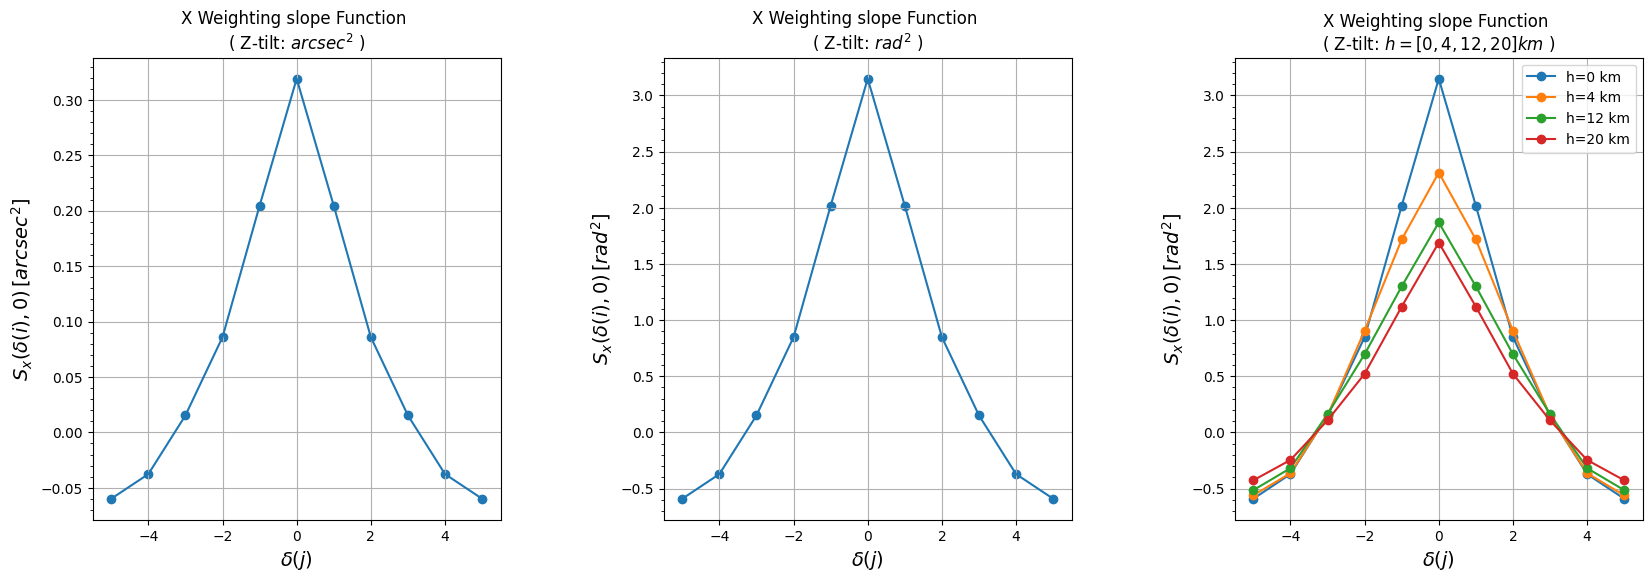

In [2]:
# --- Imports ---

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np
from TTsubstraction import tip_tilt_sub
from Gfilter import slope_weighting_function

# --- Example params ---
d = 0.047                     # sub-aperture size
nsubx = 6                     # sub-apertures 
lamda = 1280e-9               # lamda 
scalingArcsec = (1/np.pi)**2  # result on arcsec
samp = 1024                   # FFT grid size (higher => smaller df, better convergence)
cn2r0 = 1                     # Cn2 or R0
dx = d / 2                    # spatial-lag sampling for IFFT [m]; gives f_max=1/d and total bandwidth ~2/d, then stride=2 selects lags at multiples of d
pupil = np.array([[0,0,1,1,0,0], 
                  [0,1,1,1,1,0],
                  [1,1,0,0,1,1],
                  [1,1,0,0,1,1],
                  [0,1,1,1,1,0],
                  [0,0,1,1,0,0]])



## --- Result on arcsec2 ---
Arcov = slope_weighting_function(d, dx, nsubx, samp,  cn2r0=cn2r0, h=0,  wavelength=lamda, scalingFactor=scalingArcsec)

## --- Result on rad2 ---
Radcov = slope_weighting_function(d, dx, nsubx, samp, cn2r0=cn2r0, h=0 , wavelength=lamda)

## --- Diferent h ---
cov1 = slope_weighting_function(d, dx, nsubx, samp, cn2r0=cn2r0, h=0   , wavelength=lamda, scalingFactor=1)
cov2 = slope_weighting_function(d, dx, nsubx, samp, cn2r0=cn2r0, h=4e3 , wavelength=lamda, scalingFactor=1)
cov3 = slope_weighting_function(d, dx, nsubx, samp, cn2r0=cn2r0, h=12e3, wavelength=lamda, scalingFactor=1)
cov4 = slope_weighting_function(d, dx, nsubx, samp, cn2r0=cn2r0, h=20e3, wavelength=lamda, scalingFactor=1)

## --- Tip-tilt substraction ---
Apsf = tip_tilt_sub(Arcov,pupil)
Rpsf = tip_tilt_sub(Radcov,pupil)

psf1 = tip_tilt_sub(cov1, pupil)
psf2 = tip_tilt_sub(cov2, pupil)
psf3 = tip_tilt_sub(cov3, pupil)
psf4 = tip_tilt_sub(cov4, pupil)

GRID_SIZE = nsubx*2 - 1  
LAGS = 1

# --- graphs ---
fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.4)  

ax1 = fig.add_subplot(gs[0,0])
ax1.plot(np.arange(-5, 6),Apsf[1,:,5],)
ax1.scatter(np.arange(-5, 6),Apsf[1,:,5],)
ax1.set_title('X Weighting slope Function \n' + r'( Z-tilt: $arcsec^2$ )')
ax1.set_ylabel(r'$S_x(\delta(i),0)\,[arcsec^2]$', fontsize=14)
ax1.set_xlabel(r'$\delta(j)$', fontsize=14)
ax1.yaxis.set_minor_locator(AutoMinorLocator(5))  # 2 => 1 línea menor entre mayores
ax1.grid("both")

ax2 = fig.add_subplot(gs[0,1])
ax2.plot(np.arange(-5, 6),Rpsf[1,:,5],)
ax2.scatter(np.arange(-5, 6),Rpsf[1,:,5],)
ax2.set_title('X Weighting slope Function \n' + r'( Z-tilt: $rad^2$ )')
ax2.set_ylabel(r'$S_x(\delta(i),0)\,[rad^2]$', fontsize=14)
ax2.set_xlabel(r'$\delta(j)$', fontsize=14)
ax2.yaxis.set_minor_locator(AutoMinorLocator(5))  # 2 => 1 línea menor entre mayores
ax2.grid("both")

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(np.arange(-5, 6),psf1[1,:,5], "-o", label="h=0 km")
ax3.plot(np.arange(-5, 6),psf2[1,:,5], "-o", label="h=4 km")
ax3.plot(np.arange(-5, 6),psf3[1,:,5], "-o", label="h=12 km")
ax3.plot(np.arange(-5, 6),psf4[1,:,5], "-o", label="h=20 km")

ax3.set_title('X Weighting slope Function \n' + r'( Z-tilt: $ h= [0,4,12,20] km $ )')
ax3.set_ylabel(r'$S_x(\delta(i),0)\,[rad^2]$', fontsize=14)
ax3.set_xlabel(r'$\delta(j)$', fontsize=14)
ax3.grid("both")
ax3.yaxis.set_minor_locator(AutoMinorLocator(5))  # 2 => 1 línea menor entre mayores
ax3.legend()




# Tip/Tilt Subtraction with Known Matrices

To verify that the algorithms are functioning correctly up to this point, it is essential to compare the obtained results against well-established reference results. For this purpose, we use two precomputed matrices. Both are thoroughly documented and properly referenced.

**Note:** In both cases, the same wavelength will be used for the SLODAR function. This is because the Kolmogorov PSD model in the spatial domain employed here is designed to operate at a specific wavelength; changing it may lead to unexpected results. In practice, I was not fully certain how to modify this dependency.

## 1.- Traditional SHIMM

- d = 0.041 [m]
- lambda = 500 [nm]

---

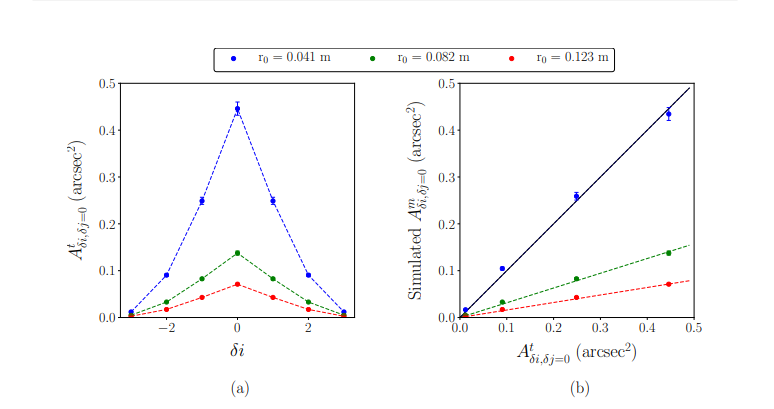

ref: Saavidra Perera, R. W. Wilson, T. Butterley, J. Osborn, O. J. D. Farley, and D. J. Laidlaw, “SHIMM: a versatile seeing monitor for astronomy,” Monthly Notices of the Royal Astronomical Society, vol. 523, no. 4, pp. 5745–5758, Aug. 2023, doi: 10.1093/mnras/stad1339.

## 1.- 24hrs SHIMM

- d = 0.047 [m]
- lambda = 1280 [nm]

---

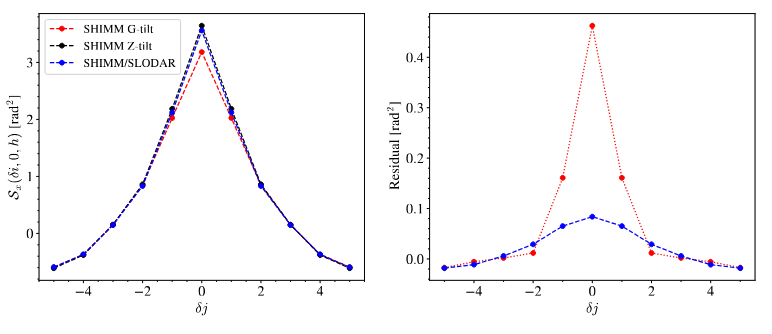

ref:R. M. Griffiths, Continuous 24-hour Shack-Hartmann optical turbulence profiling on a small telescope, Durham University, Durham E-Theses, 2024. [Online].


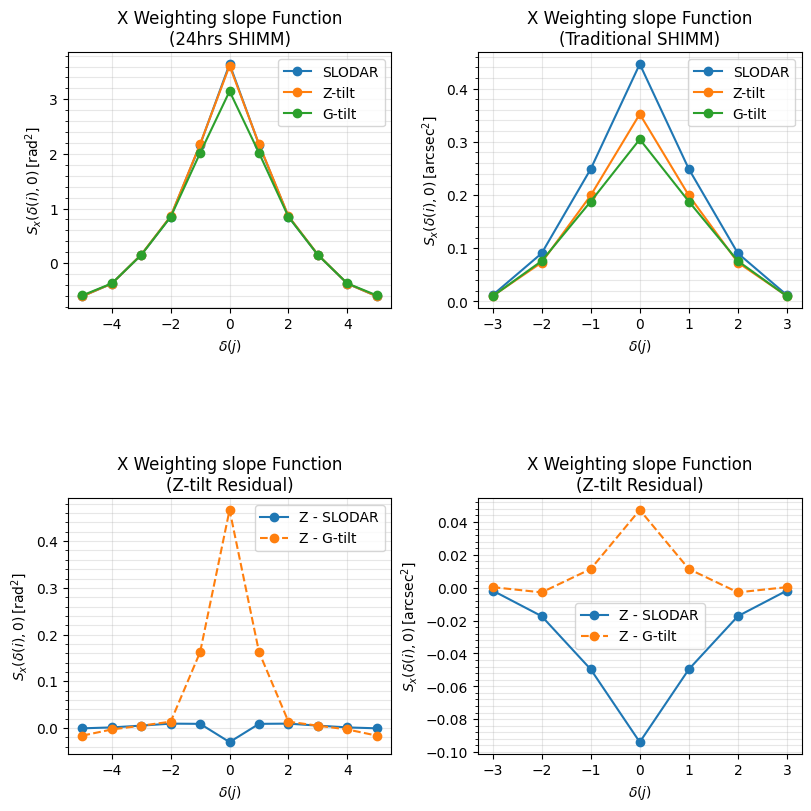

In [3]:

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np

from TTsubstraction import tip_tilt_sub
from SLODAR import slopecov_kol
from Gfilter import slope_weighting_function
from Zfilter import weighting_function

nsubx = 6       
sampling = 1024
scalingRad = np.pi **2 
cn2 = 1


# --- 24hrs SHIMM matrix data ---
Rlamda = 1280e-9
Rd = 0.047       # subaperture size
Rdx = Rd/2
Rpupil =  np.array([[0,0,1,1,0,0],
                    [0,1,1,1,1,0],
                    [1,1,0,0,1,1],
                    [1,1,0,0,1,1],
                    [0,1,1,1,1,0],
                    [0,0,1,1,0,0]])

# --- Traditional SHIMM C9 paper matrix data ---
Tlamda = 500e-9
Td = 0.041      # subaperture size
Tdx = Td/2
Tpupil = np.array([[0,0,0,0,0,0],
                   [0,1,1,1,1,0],
                   [0,1,0,0,1,0],
                   [0,1,0,0,1,0],
                   [0,1,1,1,1,0],
                   [0,0,0,0,0,0]])


# --- 24hrs SHIMM ---
tcov = slopecov_kol(nsubx,Rd, 500e-9,nsamp=8, scalingFactor=scalingRad) #<-- Rad2
Zcov = weighting_function(Rd, Rdx, nsubx, sampling,h=0, scalingFactor=1 ,cn2r0=cn2, wavelength=Rlamda, glob=False) 
Gcov = slope_weighting_function(Rd, Rdx, nsubx, sampling,h=0, scalingFactor=1 ,cn2r0=cn2, wavelength=Rlamda, glob=False)

RBpsfs = tip_tilt_sub(tcov,Rpupil) # Butterley function
RZpsfs = tip_tilt_sub(Zcov,Rpupil) # Z-tilt function
RGpsfs = tip_tilt_sub(Gcov,Rpupil) # G-tilt function


# --- Traditional SHIMM ---
tcov = slopecov_kol(nsubx, Td, Tlamda,nsamp=8,r0=1,scalingFactor=1, ) #<-- Arcsec2 
Zcov = weighting_function(Td, Tdx, nsubx, sampling, scalingFactor=1/scalingRad ,cn2r0=cn2, wavelength=Tlamda, glob=False)
Gcov = slope_weighting_function(Td, Tdx, nsubx, sampling, scalingFactor=1/scalingRad ,cn2r0=cn2, wavelength=Tlamda, glob=False)

TBpsfs = tip_tilt_sub(tcov,Tpupil) # Butterley function
TZpsfs = tip_tilt_sub(Zcov,Tpupil) # Z-tilt function
TGpsfs = tip_tilt_sub(Gcov,Tpupil) # G-tilt function

GRID_SIZE = 2 * nsubx - 1 
BEAM = 1

# --- graphs ---
fig = plt.figure(figsize=(8, 8), constrained_layout=True)  # más alto
gs = fig.add_gridspec(2, 2, wspace=0., hspace=0.25)       # menos espacio

ax1 = fig.add_subplot(gs[0,0])
x1 = np.arange(-5, 6)
ax1.plot(x1, RBpsfs[0,5,:], marker="o", label="SLODAR")
ax1.plot(x1, RZpsfs[0,5,:], marker="o", label="Z-tilt")
ax1.plot(x1, RGpsfs[0,5,:], marker="o", label="G-tilt")
ax1.set_title('X Weighting slope Function\n(24hrs SHIMM)')
ax1.set_ylabel(r'$S_x(\delta(i),0)\,[\mathrm{rad}^2]$')
ax1.set_xlabel(r'$\delta(j)$')
ax1.yaxis.set_minor_locator(AutoMinorLocator(5))  # 2 => 1 línea menor entre mayores
ax1.grid(True, which="both", alpha=0.3)
ax1.legend()

ax2 = fig.add_subplot(gs[0,1])
x2 = np.arange(-3, 4)
ax2.plot(x2, TBpsfs[0,5,2:9], marker="o", label="SLODAR")
ax2.plot(x2, TZpsfs[0,5,2:9], marker="o", label="Z-tilt")
ax2.plot(x2, TGpsfs[0,5,2:9], marker="o", label="G-tilt")
ax2.set_title('X Weighting slope Function\n(Traditional SHIMM)')
ax2.set_ylabel(r'$S_x(\delta(i),0)\,[\mathrm{arcsec}^2]$')
ax2.set_xlabel(r'$\delta(j)$')
ax2.grid(True, which="both", alpha=0.3)
ax2.yaxis.set_minor_locator(AutoMinorLocator(5))  # 2 => 1 línea menor entre mayores
ax2.legend()

ax3 = fig.add_subplot(gs[1,0])
ax3.plot(x1, RZpsfs[0,5,:]-RBpsfs[0,5,:], marker="o", label="Z - SLODAR")
ax3.plot(x1, RZpsfs[0,5,:]-RGpsfs[0,5,:], "--", marker="o", label="Z - G-tilt")
ax3.set_title('X Weighting slope Function\n(Z-tilt Residual)')
ax3.set_ylabel(r'$S_x(\delta(i),0)\,[\mathrm{rad}^2]$')
ax3.set_xlabel(r'$\delta(j)$')
ax3.grid(True, which="both", alpha=0.3)
ax3.yaxis.set_minor_locator(AutoMinorLocator(5))  # 2 => 1 línea menor entre mayores
ax3.legend()

ax4 = fig.add_subplot(gs[1,1])
ax4.plot(x2, TZpsfs[0,5,2:9]-TBpsfs[0,5,2:9], marker="o", label="Z - SLODAR")
ax4.plot(x2, TZpsfs[0,5,2:9]-TGpsfs[0,5,2:9], "--", marker="o", label="Z - G-tilt")
ax4.set_title('X Weighting slope Function\n(Z-tilt Residual)')
ax4.set_ylabel(r'$S_x(\delta(i),0)\,[\mathrm{arcsec}^2]$')
ax4.set_xlabel(r'$\delta(j)$')
ax4.yaxis.set_minor_locator(AutoMinorLocator(5))  # 2 => 1 línea menor entre mayores
ax4.grid(True, which="both", alpha=0.3)
ax4.legend()


# Conclusion:

In both cases (24hrs SHIMM and the traditional SHIMM), a good fit is observed between the computed matrices and the reference matrices. However, for the 24hrs SHIMM reference, when compared to the implementation, presented here the peak associated with SLODAR appears higher than that of the Z-tilt method. This suggests that the SLODAR version used to generate the reference does not employ exactly the same implementation as the original.

For the traditional method, the pronounced differences observed in the Z-tilt and SLODAR peaks is more evident in the traditional SHIMM plot may be explained by how both algorithms handle the variables $r_0$ or $C_n^2$. The Z-tilt model uses a power spectrum that accounts for the contribution of an individual layer at a propagation distance $h$, whereas the traditional SLODAR model relies on an integrated approach that aggregates the contribution of all layers, assuming that the overall turbulence strength satisfies $r_0 = d$. This leads to a much more pronounced variance as the sub-aperture size is modified, since this also increases the effective turbulence strength, which in turn increases the centroid variance. Consequently, the variance predicted by one method appears amplified relative to the other.


# Scintillation Weighting function:

---

Finally, the scintillation matrices are presented below to demonstrate their behavior. For this purpose, well-known reference matrices will be used again.

- $d = 0.047$
- $\lambda = 1280\,\mathrm{nm}$

---

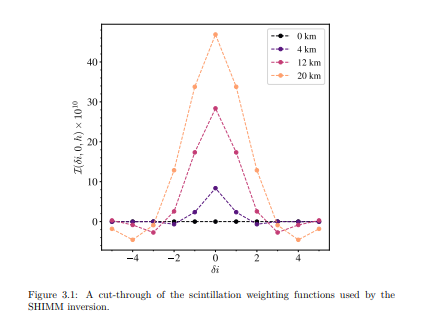

ref:R. M. Griffiths, Continuous 24-hour Shack-Hartmann optical turbulence profiling on a small telescope, Durham University, Durham E-Theses, 2024. [Online].


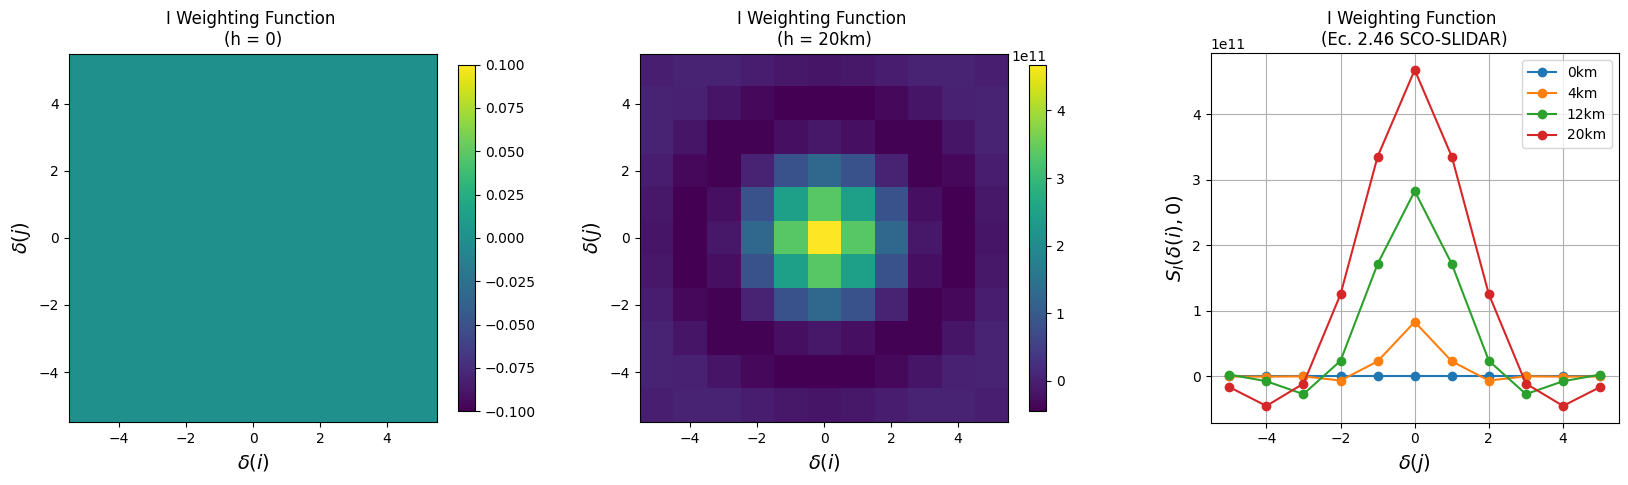

In [4]:
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np

from Gfilter import scintillation_weighting_function


# --- Example params ---

d = 0.047       # sub-aperture size
lamda = 1280e-9 # wavelength
nsubx = 6       # sub-apertures 
samp = 1024     # sampling
cn2 = 1
dx = d/2

pupil = np.array([[0,0,1,1,0,0], 
                  [0,1,1,1,1,0],
                  [1,1,0,0,1,1],
                  [1,1,0,0,1,1],
                  [0,1,1,1,1,0],
                  [0,0,1,1,0,0]])

tcov1 = scintillation_weighting_function(d, dx, nsubx, samp,scalingFactor=1, h=0e3 , cn2r0=cn2, wavelength=lamda, glob = False)
tcov2 = scintillation_weighting_function(d, dx, nsubx, samp,scalingFactor=1, h=4e3 , cn2r0=cn2, wavelength=lamda, glob = False)
tcov3 = scintillation_weighting_function(d, dx, nsubx, samp,scalingFactor=1, h=12e3, cn2r0=cn2, wavelength=lamda, glob = False)
tcov4 = scintillation_weighting_function(d, dx, nsubx, samp,scalingFactor=1, h=20e3, cn2r0=cn2, wavelength=lamda, glob = False)

GRID_SIZE = 2 * nsubx - 1
BEAM = 1

# --- graphs ---

fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1], wspace=0.4)  

ax1 = fig.add_subplot(gs[0, 0])
im1 = ax1.imshow(tcov1,
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax1.set_title('I Weighting Function \n(h = 0)')
ax1.set_xlabel(r'$\delta(i)$', fontsize=14)
ax1.set_ylabel(r'$\delta(j)$', fontsize=14)
fig.colorbar(im1, ax=ax1, shrink=0.75, fraction=0.046)

ax2 = fig.add_subplot(gs[0, 1])
im2 = ax2.imshow(tcov4,
                 extent=(-GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2, -GRID_SIZE*BEAM/2, GRID_SIZE*BEAM/2))
ax2.set_title('I Weighting Function \n(h = 20km)')
ax2.set_xlabel(r'$\delta(i)$', fontsize=14)
ax2.set_ylabel(r'$\delta(j)$', fontsize=14)
fig.colorbar(im2, ax=ax2, shrink=0.75, fraction=0.046)

ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(np.arange(-5, 6),tcov1[5,:],'-o', label="0km")
ax3.plot(np.arange(-5, 6),tcov2[5,:],'-o', label="4km")
ax3.plot(np.arange(-5, 6),tcov3[5,:],'-o', label="12km")
ax3.plot(np.arange(-5, 6),tcov4[5,:],'-o', label="20km")
ax3.set_title('I Weighting Function \n(Ec. 2.46 SCO-SLIDAR)')
ax3.set_ylabel(r'$S_I(\delta(i),0)$', fontsize=14)
ax3.set_xlabel(r'$\delta(j)$', fontsize=14)
ax3.grid("on")

ax3.legend()
pos = ax3.get_position()
ax3.set_position([pos.x0, pos.y0 + pos.height*0.1, pos.width, pos.height*0.8])